In [1]:
!pip install control

In [2]:
import control as ctrl
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_discrete_are

In [3]:
tf = ctrl.tf([0, 10], [1, 3, 10]);
print(tf)

<TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

        10
  --------------
  s^2 + 3 s + 10


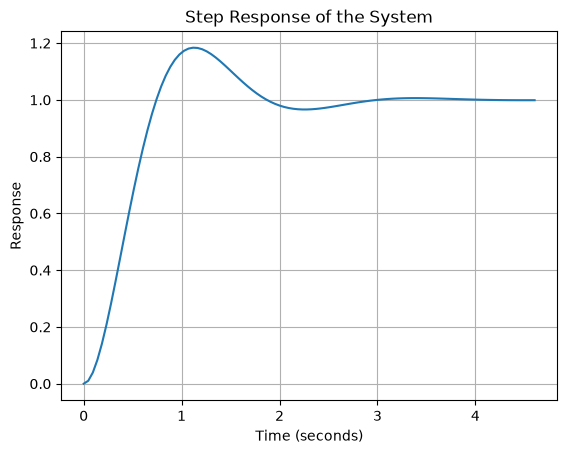

In [4]:
time, response = ctrl.step_response(tf)

plt.plot(time, response)
plt.title('Step Response of the System')
plt.xlabel('Time (seconds)')
plt.ylabel('Response')
plt.grid(True)
plt.show()

In [6]:
info = ctrl.step_info(tf)


max_value = info['Peak']
time_of_max = info['PeakTime']
settling_time = info['SettlingTime']

print(f"Максимальне значення: {max_value}")
print(f"Час досягнення максимального значення: {time_of_max}")
print(f"Час встановлення: {settling_time}")

Максимальне значення: 1.1838785400060554
Час досягнення максимального значення: 1.1164048935728705
Час встановлення: 2.6514616222355674


In [7]:
print(tf.poles())

[-1.5+2.78388218j -1.5-2.78388218j]


Система стійка оскільки усі полюси лежать у лівій частині площини

Ми використовуємо цю статтю для того аби побудувати нелінійну модель та ліанеризовану модель маятника [стаття](https://www.cureusjournals.com/articles/8517-modeling-and-balancing-control-of-inverted-pendulum#!/)

In [8]:
from dataclasses import dataclass


@dataclass
class CartPendulum:
    M: float = 1.0    # cart mass [kg]
    m: float = 0.2    # pendulum mass [kg]
    l: float = 0.5    # pivot -> pendulum centre of mass [m]
    I: float = 0.0    # inertia about the COM [kg m^2]
                      #   0            -> point mass on a massless rod
                      #   m*l**2 / 3   -> uniform rod of length 2*l
    g: float = 9.81
    b: float = 0.0    # viscous friction on the cart [N.s/m]

    def accelerations(self, th, dx, dth, u):
        """Solve the 2x2 mass matrix for (x_dd, th_dd)

        [ M+m          m·l·cos θ ] [ ẍ ] = [ m·l·θ̇²·sin θ − b·ẋ ] + [ u ]
        [ m·l·cos θ    m·l² + I  ] [ θ̈ ] = [ -m·g·l·sin θ]        + [ 0 ]

        """
        s, cth = np.sin(th), np.cos(th)
        a11 = self.M + self.m
        a12 = self.m * self.l * cth
        a22 = self.I + self.m * self.l ** 2

        r1 = self.m * self.l * dth ** 2 * s + u - self.b * dx
        r2 = -self.m * self.g * self.l * s

        det = a11 * a22 - a12 ** 2
        ddx = (a22 * r1 - a12 * r2) / det
        ddth = (a11 * r2 - a12 * r1) / det
        return ddx.item(), ddth.item()

    # state = theta, dtheta, x, dx
    def state_derivative(self, state, u):
        th, dth, x, dx = state[0], state[1], state[2], state[3]
        ddx, ddth = self.accelerations(th, dx, dth, u)
        return np.asarray([dth, ddth, dx, ddx])

    # integrate using RK4
    def step(self, state, u, h):
        k1 = self.state_derivative(state, u)
        k2 = self.state_derivative(state + h * k1 * 0.5, u)
        k3 = self.state_derivative(state + h * k2 * 0.5, u)
        k4 = self.state_derivative(state + h * k3, u)

        state_updated = state + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

        return state_updated

    def get_lianerized_continious_AB(self):
        q = self.I * (self.M + self.m) + self.M * self.m * self.l * self.l
        A = np.asarray([
            [0, 1, 0, 0],
            [(self.M + self.m) * self.m * self.l * self.g / q, 0, 0, -self.m * self.l * self.b / q],
            [0, 0, 0, 1],
            [self.m * self.m * self.l * self.l * self.g / q, 0, 0, -self.b*(self.I + self.m * self.l * self.l) / q]
            ])
        B = np.asarray([
            0,
            self.m * self.l / q,
            0,
            (self.I + self.m * self.l * self.l) / q
        ])

        return A, B


In [9]:
nonlinear_sys = CartPendulum(M=3, m=1.57, b=0.1, l=2, I=2.0933, g=9.81)

#Створюємо неперервну систему
Ac, Bc = nonlinear_sys.get_lianerized_continious_AB()
csys = ctrl.ss(Ac, Bc, np.eye(4), np.zeros((4, 1)))

#Дискретизуємо її
h = 0.01

discrete_lianerized_system = ctrl.c2d(csys, h)
A_d = discrete_lianerized_system.A
B_d = discrete_lianerized_system.B

# Використовуємо LQR регулятор
# theta, dtheta, x, dx
Q = np.diag([10, 1, 5, 1])
R = np.diag([0.1])

K, S, E = ctrl.dlqr(A_d, B_d, Q, R)

print("Власні значення замкненого контуру керування: ", E)

Власні значення замкненого контуру керування:  [0.99026986+0.00733497j 0.99026986-0.00733497j 0.97770772+0.00175764j
 0.97770772-0.00175764j]


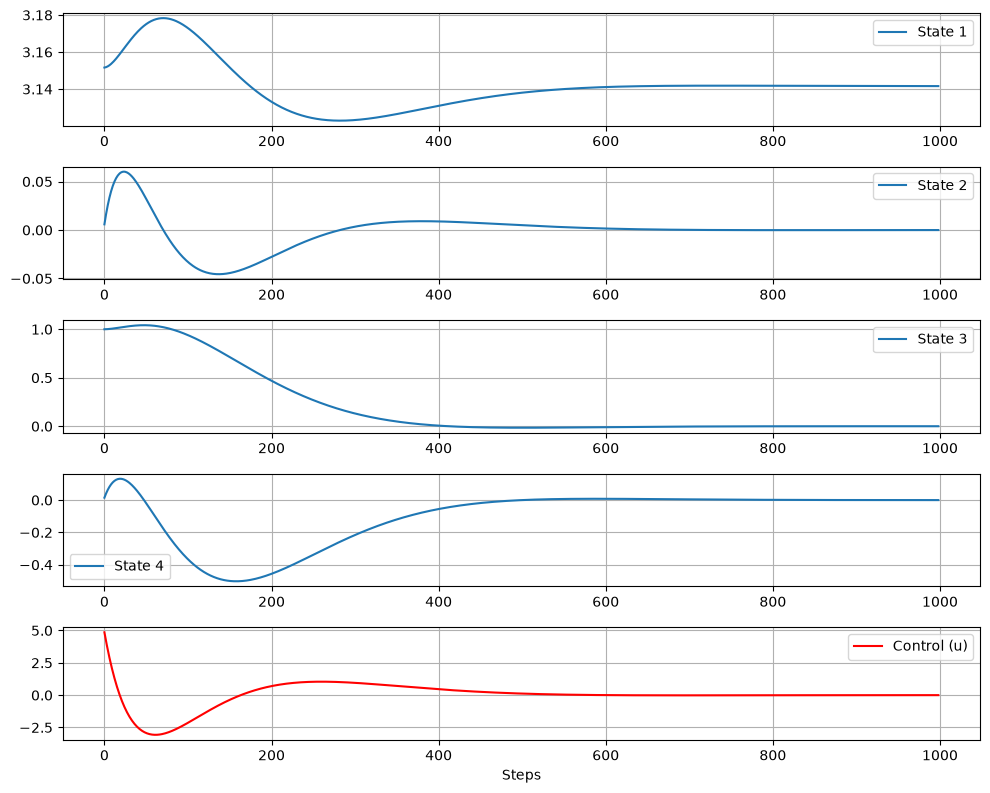

In [10]:
state_history = []
control_history = []

# theta, dtheta, x, dx
x_ref = np.asarray([np.pi, 0, 0, 0])
x = np.asarray([np.pi + 0.01, 0, 1, 0])

for step in range(1, 1000):
    u = -K @ (x - x_ref)
    x = nonlinear_sys.step(x, u, h)

    state_history.append(x)
    control_history.append(u)

state_history = np.array(state_history)
control_history = np.array(control_history)

plt.figure(figsize=(10, 8))

for i in range(4):
    plt.subplot(5, 1, i + 1)
    plt.plot(state_history[:, i], label=f'State {i+1}')
    plt.grid(True)
    plt.legend()

plt.subplot(5, 1, 5)
plt.plot(control_history, label='Control (u)', color='red')
plt.grid(True)
plt.legend()
plt.xlabel('Steps')

plt.tight_layout()
plt.show()
